# 09 — Feature-Based Benign One-Class Modelling for Malignant-Case Detection

This notebook implements the anomaly-detection component of the dissertation:

**ROI-Guided Attention Supervision for Explainable Breast Cancer Classification and Anomaly Detection in Mammograms**

Important scope statement:

CBIS-DDSM mass cases do **not** contain truly normal mammograms. Every image in this experiment contains a radiologist-identified abnormality. Therefore, this notebook does **not** claim normal-vs-abnormal screening anomaly detection. It tests a narrower and scientifically safer question:

> Can a model fitted only on benign mass-case features assign higher anomaly scores to malignant mass cases?

The anomaly detectors are trained using **benign training images only**. Thresholds are selected using the validation split only, and the locked test set is evaluated once.

Default encoder:

- ResNet-50 V2 breast-crop 512 checkpoint: `resnet50_v2_breastcrop_512_best.pth`
- This keeps the anomaly experiment independent of the ROI-attention and multimodal models.
- Because the encoder was supervised during V2 classification training, the anomaly detector should be described as **one-class modelling in a supervised feature space**, not as a fully unsupervised raw-image detector.

Primary anomaly methods:

- Mahalanobis distance with PCA + Ledoit-Wolf covariance fitted on benign training features.
- Isolation Forest fitted on benign training features.

## 1. Setup

The notebook reuses the exact V2 patient-level split and locked CBIS-DDSM mass test set. It creates a separate output folder so existing classification, ROI-supervision and multimodal results are not overwritten.

In [14]:
from google.colab import drive
drive.mount("/content/drive")

import os, json, random, shutil, platform
from datetime import datetime
import hashlib

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

try:
    RESAMPLE_BILINEAR = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE_BILINEAR = Image.BILINEAR


# ============================================================
# Project paths
# ============================================================

PROJECT_CANDIDATES = [
    "/content/drive/MyDrive/BreastCancer_dissertation",
    "/content/gdrive_fresh/MyDrive/BreastCancer_dissertation",
]

PROJECT_DIR = next(
    (p for p in PROJECT_CANDIDATES if os.path.exists(p)),
    PROJECT_CANDIDATES[0],
)

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "Data",
    "CBIS-DDSM",
)

JPEG_DIR = os.path.join(
    DATA_DIR,
    "jpeg",
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "Models",
)

V2_OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Results",
    "resnet50_v2_breastcrop_512",
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Results",
    "anomaly_detection_oneclass",
)

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# Required CSV and checkpoint paths
# ============================================================

TRAIN_CSV = os.path.join(
    DATA_DIR,
    "mass_case_description_train_set.csv",
)

TEST_CSV = os.path.join(
    DATA_DIR,
    "mass_case_description_test_set.csv",
)

DICOM_INFO_CSV = os.path.join(
    DATA_DIR,
    "dicom_info.csv",
)

V2_SPLIT_CSV = os.path.join(
    V2_OUTPUT_DIR,
    "split_assignments.csv",
)

V2_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "resnet50_v2_breastcrop_512_best.pth",
)


# ============================================================
# Experiment configuration
# ============================================================

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 16
NUM_WORKERS = 0
BOOTSTRAP_N = 1000
MAX_PCA_COMPONENTS = 128
PCA_VARIANCE_TARGET = 0.95

PREPROCESS_VERSION = "breastcrop_v5_anomaly"

CACHE_DIR = (
    f"/content/cbis_cache_"
    f"{PREPROCESS_VERSION}_{IMG_SIZE}"
)

FEATURE_CACHE = os.path.join(
    OUTPUT_DIR,
    "features_resnet50_v2_breastcrop512.npz",
)


# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = bool(torch.cuda.is_available())


# ============================================================
# Environment information
# ============================================================

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("JPEG directory:", JPEG_DIR)
print("Output directory:", OUTPUT_DIR)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)


# ============================================================
# Required-file checks
# ============================================================

required_files = {
    "Training CSV": TRAIN_CSV,
    "Test CSV": TEST_CSV,
    "DICOM metadata CSV": DICOM_INFO_CSV,
    "V2 split assignments": V2_SPLIT_CSV,
    "V2 ResNet checkpoint": V2_MODEL_PATH,
}

print("\nRequired files:")

missing_files = []

for description, path in required_files.items():
    exists = os.path.isfile(path)
    print(
        f"{description}: "
        f"{'FOUND' if exists else 'MISSING'}\n"
        f"  {path}"
    )

    if not exists:
        missing_files.append(
            f"{description}: {path}"
        )

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(
            f"- {item}" for item in missing_files
        )
    )

print("\nAll required files were found.")


# ============================================================
# Checkpoint fingerprinting
# ============================================================

def file_sha256(
    path,
    block_size=1024 * 1024,
):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(
            lambda: f.read(block_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def checkpoint_fingerprint(path):
    if not os.path.exists(path):
        return {
            "path": path,
            "exists": False,
        }

    return {
        "path": path,
        "exists": True,
        "size_bytes": int(
            os.path.getsize(path)
        ),
        "mtime": float(
            os.path.getmtime(path)
        ),
        "sha256": file_sha256(path),
    }


V2_CHECKPOINT_FINGERPRINT = checkpoint_fingerprint(
    V2_MODEL_PATH
)

print(
    "\nV2 checkpoint SHA-256:",
    V2_CHECKPOINT_FINGERPRINT["sha256"],
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/BreastCancer_dissertation
Data directory: /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM
JPEG directory: /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/jpeg
Output directory: /content/drive/MyDrive/BreastCancer_dissertation/Results/anomaly_detection_oneclass
Device: cuda
GPU: Tesla T4
Python: 3.12.13
PyTorch: 2.11.0+cu128

Required files:
Training CSV: FOUND
  /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/mass_case_description_train_set.csv
Test CSV: FOUND
  /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/mass_case_description_test_set.csv
DICOM metadata CSV: FOUND
  /content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/dicom_info.csv
V2 split assignments: FOUND
  /content/drive/MyDrive/BreastCancer_dissertation/Results/resnet50_v2_breastcro

## 2. Image-Level CBIS-DDSM Mass Dataset

Rows in CBIS-DDSM are abnormality-level records. For image-level modelling, records are grouped into one mammogram per patient-side-view. The label is malignant if any abnormality on that mammogram is malignant.

In [15]:
ALLOWED_PATHOLOGY = {
    "BENIGN",
    "BENIGN_WITHOUT_CALLBACK",
    "MALIGNANT",
}


def find_csv(name_or_path):
    """
    Accept either:
    - a complete CSV path, or
    - a CSV filename to search for inside DATA_DIR.
    """

    # Cell 1 now supplies complete paths
    if os.path.isfile(name_or_path):
        return name_or_path

    filename = os.path.basename(name_or_path)

    candidates = [
        os.path.join(DATA_DIR, filename),
        os.path.join(DATA_DIR, "csv", filename),
    ]

    for path in candidates:
        if os.path.isfile(path):
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. Searched:\n"
        + "\n".join(f"  - {path}" for path in candidates)
    )


def uid_from(path):
    parts = str(path).replace("\\", "/").split("/")

    if len(parts) < 2:
        return ""

    return parts[-2]


def jpegs_from_metadata_path(metadata_path):
    uid = uid_from(metadata_path)

    if not uid:
        return []

    folder = os.path.join(JPEG_DIR, uid)

    if not os.path.isdir(folder):
        return []

    return [
        os.path.join(folder, filename)
        for filename in sorted(os.listdir(folder))
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]


def first_jpeg(metadata_path):
    files = jpegs_from_metadata_path(metadata_path)
    return files[0] if files else None


def join_unique(values):
    output = []

    for value in values:
        if pd.isna(value):
            continue

        value = str(value).strip()

        if value and value not in output:
            output.append(value)

    return "||".join(output)


def aggregate_unique(values):
    cleaned = {
        str(value).strip()
        for value in values
        if not pd.isna(value)
        and str(value).strip()
    }

    return "; ".join(sorted(cleaned))


def build_image_level_df(case_csv, split_source):
    csv_path = find_csv(case_csv)

    print(f"\nLoading {split_source} CSV:")
    print(csv_path)

    raw = pd.read_csv(csv_path)

    required_columns = [
        "patient_id",
        "left or right breast",
        "image view",
        "pathology",
        "assessment",
        "breast_density",
        "mass shape",
        "mass margins",
        "image file path",
        "ROI mask file path",
        "cropped image file path",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in raw.columns
    ]

    if missing_columns:
        raise KeyError(
            "Required columns are missing from the CSV:\n"
            + "\n".join(
                f"- {column}"
                for column in missing_columns
            )
        )

    pathology = (
        raw["pathology"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    observed_pathologies = set(
        pathology[pathology != ""].unique()
    )

    unexpected = (
        observed_pathologies - ALLOWED_PATHOLOGY
    )

    assert not unexpected, (
        f"Unexpected pathology values found: "
        f"{sorted(unexpected)}"
    )

    raw["pathology"] = pathology

    raw["label"] = (
        pathology == "MALIGNANT"
    ).astype(int)

    raw["full_jpeg"] = (
        raw["image file path"]
        .apply(first_jpeg)
    )

    missing_jpeg_count = int(
        raw["full_jpeg"].isna().sum()
    )

    print("Original rows:", len(raw))
    print("Rows with located JPEG:", raw["full_jpeg"].notna().sum())
    print("Rows without located JPEG:", missing_jpeg_count)

    df = (
        raw
        .dropna(subset=["full_jpeg"])
        .groupby(
            [
                "patient_id",
                "left or right breast",
                "image view",
            ],
            as_index=False,
        )
        .agg(
            full_jpeg=("full_jpeg", "first"),
            label=("label", "max"),
            pathology=(
                "pathology",
                aggregate_unique,
            ),
            assessment=(
                "assessment",
                aggregate_unique,
            ),
            breast_density=(
                "breast_density",
                "first",
            ),
            mass_shape=(
                "mass shape",
                aggregate_unique,
            ),
            mass_margins=(
                "mass margins",
                aggregate_unique,
            ),
            roi_mask_paths=(
                "ROI mask file path",
                join_unique,
            ),
            cropped_paths=(
                "cropped image file path",
                join_unique,
            ),
        )
        .reset_index(drop=True)
    )

    df["split_source"] = split_source

    df["sample_id"] = (
        df["patient_id"].astype(str)
        + "|"
        + df["left or right breast"].astype(str)
        + "|"
        + df["image view"].astype(str)
    )

    df["label"] = df["label"].astype(int)

    assert df["sample_id"].is_unique, (
        f"Duplicate sample IDs found in {split_source}."
    )

    assert set(df["label"].unique()).issubset(
        {0, 1}
    )

    if len(df) == 0:
        raise RuntimeError(
            f"No usable images were found for {split_source}. "
            f"Check JPEG_DIR: {JPEG_DIR}"
        )

    return df


# Build image-level datasets
img_df_train = build_image_level_df(
    TRAIN_CSV,
    "development",
)

img_df_test = build_image_level_df(
    TEST_CSV,
    "locked_test",
)


# Dataset summary
summary = pd.DataFrame(
    [
        {
            "split": "development",
            "images": len(img_df_train),
            "patients": (
                img_df_train["patient_id"].nunique()
            ),
            "benign": int(
                (img_df_train["label"] == 0).sum()
            ),
            "malignant": int(
                (img_df_train["label"] == 1).sum()
            ),
            "malignant_rate": (
                img_df_train["label"].mean()
            ),
        },
        {
            "split": "locked_test",
            "images": len(img_df_test),
            "patients": (
                img_df_test["patient_id"].nunique()
            ),
            "benign": int(
                (img_df_test["label"] == 0).sum()
            ),
            "malignant": int(
                (img_df_test["label"] == 1).sum()
            ),
            "malignant_rate": (
                img_df_test["label"].mean()
            ),
        },
    ]
)

display(summary.round(4))

print("\nCell 2 completed successfully.")


Loading development CSV:
/content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/mass_case_description_train_set.csv
Original rows: 1318
Rows with located JPEG: 1318
Rows without located JPEG: 0

Loading locked_test CSV:
/content/drive/MyDrive/BreastCancer_dissertation/Data/CBIS-DDSM/mass_case_description_test_set.csv
Original rows: 378
Rows with located JPEG: 378
Rows without located JPEG: 0


,split,images,patients,benign,malignant,malignant_rate
0,development,1231,691,629,602,0.4890
1,locked_test,361,201,216,145,0.4017



Cell 2 completed successfully.


## 3. Exact V2 Split Reuse

The anomaly experiment uses the same patient-level V2 train/validation split and official locked test set. No new split is generated.

In [16]:
if not os.path.exists(V2_SPLIT_CSV):
    raise FileNotFoundError(
        f"V2 split file not found: {V2_SPLIT_CSV}\n"
        "Run the ResNet-50 V2 notebook first so all later experiments share the same split."
    )

v2 = pd.read_csv(V2_SPLIT_CSV)
assert {"sample_id", "split"}.issubset(v2.columns), "V2 split file must contain sample_id and split columns."
v2["split"] = (
    v2["split"].astype(str).str.strip().str.lower()
      .replace({"val": "validation", "valid": "validation", "locked test": "locked_test"})
)

tr_ids = set(v2.loc[v2.split == "train", "sample_id"])
va_ids = set(v2.loc[v2.split == "validation", "sample_id"])
te_ids = set(v2.loc[v2.split.isin(["locked_test", "test"]), "sample_id"])

train_df = img_df_train[img_df_train.sample_id.isin(tr_ids)].reset_index(drop=True)
val_df = img_df_train[img_df_train.sample_id.isin(va_ids)].reset_index(drop=True)
test_df = img_df_test.reset_index(drop=True)

assert set(train_df.sample_id) == tr_ids, "Train IDs do not match V2 split."
assert set(val_df.sample_id) == va_ids, "Validation IDs do not match V2 split."
if te_ids:
    assert set(test_df.sample_id) == te_ids, "Locked-test IDs do not match V2 split."

for a, b in [(train_df, val_df), (train_df, test_df), (val_df, test_df)]:
    assert set(a.patient_id).isdisjoint(set(b.patient_id)), "Patient leakage across splits."

split_summary = pd.DataFrame([
    {"split": "train", "images": len(train_df), "patients": train_df.patient_id.nunique(), "malignant_rate": train_df.label.mean(), "benign_images": int((train_df.label == 0).sum())},
    {"split": "validation", "images": len(val_df), "patients": val_df.patient_id.nunique(), "malignant_rate": val_df.label.mean(), "benign_images": int((val_df.label == 0).sum())},
    {"split": "locked_test", "images": len(test_df), "patients": test_df.patient_id.nunique(), "malignant_rate": test_df.label.mean(), "benign_images": int((test_df.label == 0).sum())},
])
display(split_summary.round(4))
split_summary.to_csv(os.path.join(OUTPUT_DIR, "split_summary.csv"), index=False)
pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="validation"),
    test_df.assign(split="locked_test"),
])[["sample_id", "patient_id", "label", "split"]].to_csv(
    os.path.join(OUTPUT_DIR, "exact_split_assignments.csv"),
    index=False,
)
print("Exact V2 split confirmed.")

,split,images,patients,malignant_rate,benign_images
0,train,1051,592,0.4805,546
1,validation,180,99,0.5389,83
2,locked_test,361,201,0.4017,216


Exact V2 split confirmed.


## 4. V2 Breast-Crop Preprocessing

The same breast crop, aspect-ratio preserving padding and 512 x 512 resizing used in the V2 ResNet baseline is reused here. This makes the feature-based anomaly detector directly comparable with the previous image-only model.

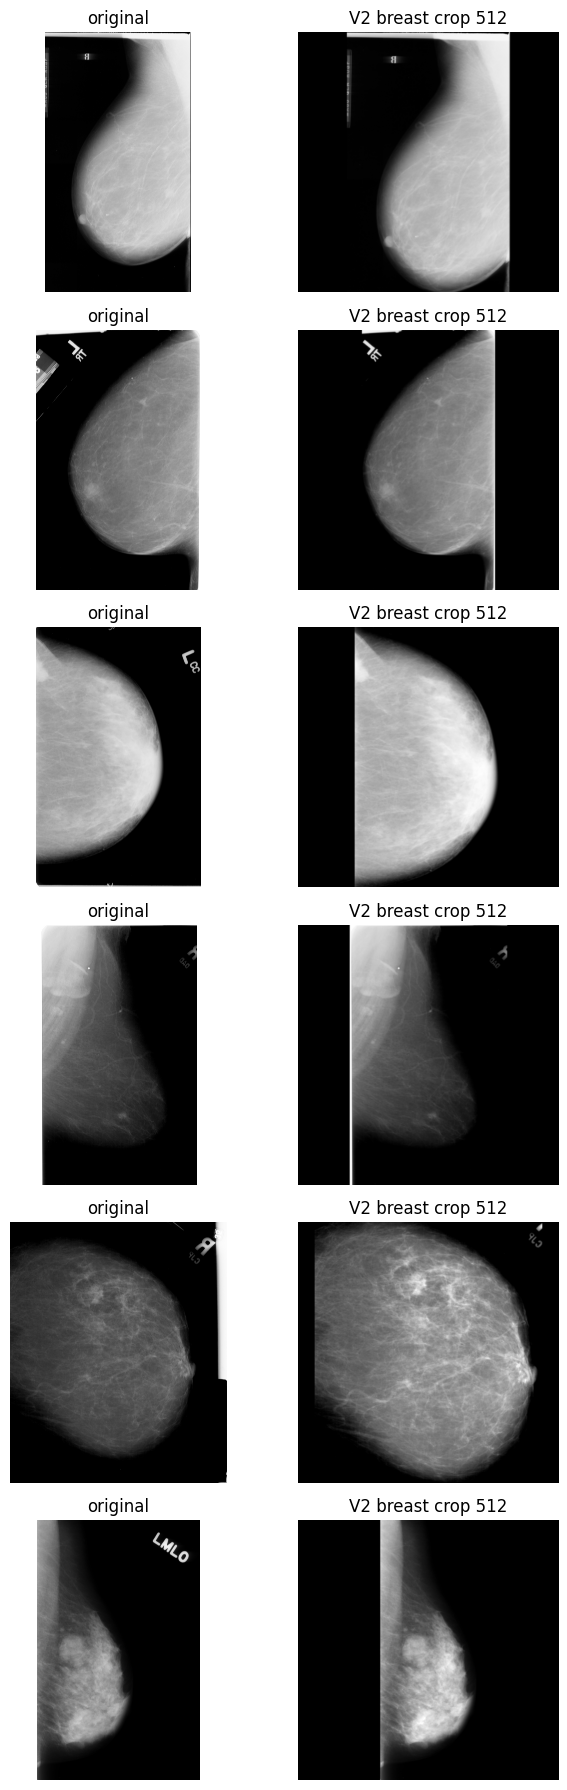

In [17]:
def otsu_threshold(gray):
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    prob = hist / max(gray.size, 1)
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]
    sigma = (mu_t * omega - mu) ** 2 / np.maximum(omega * (1 - omega), 1e-12)
    sigma[(omega <= 0) | (omega >= 1)] = 0
    return int(np.argmax(sigma))

def breast_bbox(gray_u8, pad_frac=0.02):
    h, w = gray_u8.shape
    mask = gray_u8 > max(otsu_threshold(gray_u8), 5)
    mask = ndimage.binary_opening(mask, structure=np.ones((3, 3)))
    mask = ndimage.binary_closing(mask, structure=np.ones((7, 7)))
    labels, n_labels = ndimage.label(mask)
    if n_labels == 0:
        return (0, 0, w, h)
    counts = np.bincount(labels.ravel())
    counts[0] = 0
    ys, xs = np.where(labels == counts.argmax())
    if len(xs) == 0:
        return (0, 0, w, h)
    pad = int(round(pad_frac * max(h, w)))
    return (
        max(int(xs.min()) - pad, 0),
        max(int(ys.min()) - pad, 0),
        min(int(xs.max()) + 1 + pad, w),
        min(int(ys.max()) + 1 + pad, h),
    )

def load_gray(path):
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)

def crop_pad_resize_image(gray_u8, bbox, size=IMG_SIZE):
    left, top, right, bottom = bbox
    crop = Image.fromarray(gray_u8).crop((left, top, right, bottom))
    cw, ch = crop.size
    side = max(cw, ch)
    canvas = Image.new("L", (side, side), 0)
    canvas.paste(crop, ((side - cw) // 2, (side - ch) // 2))
    return np.array(canvas.resize((size, size), RESAMPLE_BILINEAR), dtype=np.uint8)

def preprocess_mammogram(path):
    original = load_gray(path)
    bbox = breast_bbox(original)
    processed = crop_pad_resize_image(original, bbox)
    return processed

def safe_sid(sample_id):
    return str(sample_id).replace("|", "_")

def cache_path(sample_id):
    return os.path.join(CACHE_DIR, "img", safe_sid(sample_id) + ".png")

def meta_path(sample_id):
    return os.path.join(CACHE_DIR, "meta", safe_sid(sample_id) + ".json")

def cache_signature(row):
    return {
        "preprocess_version": PREPROCESS_VERSION,
        "sample_id": str(row.sample_id),
        "full_jpeg": str(row.full_jpeg),
        "img_size": int(IMG_SIZE),
    }

def cache_valid(row):
    if not (os.path.exists(cache_path(row.sample_id)) and os.path.exists(meta_path(row.sample_id))):
        return False
    try:
        with open(meta_path(row.sample_id), "r") as f:
            old = json.load(f)
    except Exception:
        return False
    return old == cache_signature(row)

def build_image_cache(df, name):
    os.makedirs(os.path.join(CACHE_DIR, "img"), exist_ok=True)
    os.makedirs(os.path.join(CACHE_DIR, "meta"), exist_ok=True)
    rebuilt = 0
    for row in tqdm(df.itertuples(), total=len(df), desc=f"preprocess {name}"):
        if cache_valid(row):
            continue
        processed = preprocess_mammogram(row.full_jpeg)
        Image.fromarray(processed).save(cache_path(row.sample_id))
        with open(meta_path(row.sample_id), "w") as f:
            json.dump(cache_signature(row), f, indent=2)
        rebuilt += 1
    print(f"{name}: rebuilt {rebuilt}/{len(df)} cached images")

def show_training_crop_examples(n=6):
    ex = train_df.sample(min(n, len(train_df)), random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(len(ex), 2, figsize=(7, 3.0 * len(ex)))
    if len(ex) == 1:
        axes = np.array([axes])
    for i, row in ex.iterrows():
        original = load_gray(row.full_jpeg)
        processed = preprocess_mammogram(row.full_jpeg)
        axes[i, 0].imshow(original, cmap="gray")
        axes[i, 0].set_title("original")
        axes[i, 1].imshow(processed, cmap="gray")
        axes[i, 1].set_title("V2 breast crop 512")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_training_crop_examples()

## 5. Feature Extraction with Frozen ResNet-50 V2 Encoder

The feature extractor is the trained V2 ResNet-50 with its classification head replaced by identity, producing a 2048-dimensional feature vector per mammogram. Features are cached to Google Drive so later anomaly-model cells can be rerun without re-extracting images.

In [18]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class FeatureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(cache_path(row.sample_id)).convert("L")
        arr = np.stack([np.array(img, dtype=np.float32) / 255.0] * 3, axis=0)
        tensor = torch.from_numpy(arr)
        tensor = (tensor - IMAGENET_MEAN) / IMAGENET_STD
        return {
            "image": tensor.float(),
            "label": int(row.label),
            "sample_id": str(row.sample_id),
            "patient_id": str(row.patient_id),
        }

def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state = checkpoint["state_dict"]
    else:
        state = checkpoint
    if not isinstance(state, dict):
        raise TypeError("Checkpoint does not contain a PyTorch state dictionary.")
    return {str(k).removeprefix("module."): v for k, v in state.items()}

def build_resnet50_encoder():
    if not os.path.exists(V2_MODEL_PATH):
        raise FileNotFoundError(
            f"V2 checkpoint not found: {V2_MODEL_PATH}\n"
            "Run the ResNet-50 V2 notebook first, or change V2_MODEL_PATH to the correct checkpoint."
        )
    checkpoint = torch.load(V2_MODEL_PATH, map_location="cpu")
    state = extract_state_dict(checkpoint)
    assert "fc.weight" in state, "Checkpoint state dict does not contain fc.weight."
    out_dim = state["fc.weight"].shape[0] if "fc.weight" in state else 1
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, out_dim)
    model.load_state_dict(state, strict=True)
    model.fc = nn.Identity()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(device)

def extract_features_split(model, df, name):
    loader = DataLoader(
        FeatureDataset(df),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    feats, labels, sample_ids, patient_ids = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"features {name}"):
            z = model(batch["image"].to(device)).detach().cpu().numpy()
            feats.append(z)
            labels.extend([int(x) for x in batch["label"]])
            sample_ids.extend([str(x) for x in batch["sample_id"]])
            patient_ids.extend([str(x) for x in batch["patient_id"]])
    return {
        "X": np.vstack(feats).astype(np.float32),
        "y": np.array(labels, dtype=np.int64),
        "sample_id": np.array(sample_ids),
        "patient_id": np.array(patient_ids),
    }

def feature_cache_valid():
    if not os.path.exists(FEATURE_CACHE):
        return False
    try:
        data = np.load(FEATURE_CACHE, allow_pickle=False)
        fp = json.loads(str(data["checkpoint_fingerprint"]))
        current_fp = checkpoint_fingerprint(V2_MODEL_PATH)
        ok = (
            list(data["train_sample_id"].astype(str)) == list(train_df.sample_id.astype(str)) and
            list(data["val_sample_id"].astype(str)) == list(val_df.sample_id.astype(str)) and
            list(data["test_sample_id"].astype(str)) == list(test_df.sample_id.astype(str)) and
            str(data["encoder_name"]) == "resnet50_v2_breastcrop512" and
            fp.get("sha256") == current_fp.get("sha256") and
            fp.get("size_bytes") == current_fp.get("size_bytes")
        )
        data.close()
        return bool(ok)
    except Exception:
        return False

def save_feature_cache(train_feat, val_feat, test_feat):
    np.savez_compressed(
        FEATURE_CACHE,
        encoder_name=np.array("resnet50_v2_breastcrop512"),
        checkpoint_fingerprint=np.array(json.dumps(checkpoint_fingerprint(V2_MODEL_PATH), sort_keys=True)),
        train_X=train_feat["X"], train_y=train_feat["y"], train_sample_id=train_feat["sample_id"], train_patient_id=train_feat["patient_id"],
        val_X=val_feat["X"], val_y=val_feat["y"], val_sample_id=val_feat["sample_id"], val_patient_id=val_feat["patient_id"],
        test_X=test_feat["X"], test_y=test_feat["y"], test_sample_id=test_feat["sample_id"], test_patient_id=test_feat["patient_id"],
    )

if feature_cache_valid():
    print("Loaded cached ResNet-50 V2 features:", FEATURE_CACHE)
    data = np.load(FEATURE_CACHE, allow_pickle=False)
    train_feat = {"X": data["train_X"], "y": data["train_y"], "sample_id": data["train_sample_id"].astype(str), "patient_id": data["train_patient_id"].astype(str)}
    val_feat = {"X": data["val_X"], "y": data["val_y"], "sample_id": data["val_sample_id"].astype(str), "patient_id": data["val_patient_id"].astype(str)}
    test_feat = {"X": data["test_X"], "y": data["test_y"], "sample_id": data["test_sample_id"].astype(str), "patient_id": data["test_patient_id"].astype(str)}
    data.close()
else:
    build_image_cache(train_df, "train")
    build_image_cache(val_df, "validation")
    build_image_cache(test_df, "locked_test")
    encoder = build_resnet50_encoder()
    train_feat = extract_features_split(encoder, train_df, "train")
    val_feat = extract_features_split(encoder, val_df, "validation")
    test_feat = extract_features_split(encoder, test_df, "locked_test")
    save_feature_cache(train_feat, val_feat, test_feat)
    del encoder
    torch.cuda.empty_cache()
    print("Saved feature cache:", FEATURE_CACHE)

for name, feat in [("train", train_feat), ("validation", val_feat), ("locked_test", test_feat)]:
    print(name, feat["X"].shape, "malignant rate", feat["y"].mean().round(4))

assert list(train_feat["sample_id"].astype(str)) == list(train_df.sample_id.astype(str))
assert list(val_feat["sample_id"].astype(str)) == list(val_df.sample_id.astype(str))
assert list(test_feat["sample_id"].astype(str)) == list(test_df.sample_id.astype(str))
assert np.array_equal(train_feat["y"], train_df.label.to_numpy(dtype=np.int64))
assert np.array_equal(val_feat["y"], val_df.label.to_numpy(dtype=np.int64))
assert np.array_equal(test_feat["y"], test_df.label.to_numpy(dtype=np.int64))
print("Feature/label alignment confirmed for train, validation and locked test.")

preprocess train:   0%|          | 0/1051 [00:00<?, ?it/s]

train: rebuilt 1051/1051 cached images


preprocess validation:   0%|          | 0/180 [00:00<?, ?it/s]

validation: rebuilt 180/180 cached images


preprocess locked_test:   0%|          | 0/361 [00:00<?, ?it/s]

locked_test: rebuilt 361/361 cached images


features train:   0%|          | 0/66 [00:00<?, ?it/s]

features validation:   0%|          | 0/12 [00:00<?, ?it/s]

features locked_test:   0%|          | 0/23 [00:00<?, ?it/s]

Saved feature cache: /content/drive/MyDrive/BreastCancer_dissertation/Results/anomaly_detection_oneclass/features_resnet50_v2_breastcrop512.npz
train (1051, 2048) malignant rate 0.4805
validation (180, 2048) malignant rate 0.5389
locked_test (361, 2048) malignant rate 0.4017
Feature/label alignment confirmed for train, validation and locked test.


## 6. Fit One-Class Models on Benign Training Features Only

The scaler, PCA and anomaly detectors are fitted using only benign training cases (`label = 0`). Malignant training cases are not used to fit the anomaly distribution.

PCA is fitted after standardisation to stabilise covariance estimation. The Mahalanobis model uses Ledoit-Wolf shrinkage, which is safer than an empirical covariance estimate for high-dimensional CNN features.

In [19]:
X_train = train_feat["X"]
y_train = train_feat["y"]
X_val = val_feat["X"]
y_val = val_feat["y"]
X_test = test_feat["X"]
y_test = test_feat["y"]

benign_mask = y_train == 0
assert benign_mask.sum() > 20, "Too few benign training samples for one-class modelling."

X_benign = X_train[benign_mask]
print(f"Benign training samples used for one-class fitting: {len(X_benign)} / {len(X_train)}")

scaler = StandardScaler().fit(X_benign)
Z_benign = scaler.transform(X_benign)

nmax = min(MAX_PCA_COMPONENTS, Z_benign.shape[0] - 1, Z_benign.shape[1])
pca_probe = PCA(n_components=nmax, svd_solver="full").fit(Z_benign)
cum = np.cumsum(pca_probe.explained_variance_ratio_)
if cum[-1] >= PCA_VARIANCE_TARGET:
    n_components = int(np.searchsorted(cum, PCA_VARIANCE_TARGET) + 1)
else:
    n_components = int(nmax)

pca = PCA(n_components=n_components, svd_solver="full").fit(Z_benign)
print(f"PCA components: {n_components} | variance retained: {pca.explained_variance_ratio_.sum():.3f}")

def transform_features(X):
    return pca.transform(scaler.transform(X))

Z_train = transform_features(X_train)
Z_val = transform_features(X_val)
Z_test = transform_features(X_test)
Z_benign_pca = transform_features(X_benign)

mahal = LedoitWolf().fit(Z_benign_pca)

def score_mahalanobis(Z):
    diff = Z - mahal.location_
    return np.einsum("ij,jk,ik->i", diff, mahal.precision_, diff)

iforest = IsolationForest(
    n_estimators=500,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
).fit(Z_benign_pca)

def score_iforest(Z):
    return -iforest.score_samples(Z)  # higher score = more anomalous

scores = {
    "Mahalanobis": {
        "val": score_mahalanobis(Z_val),
        "test": score_mahalanobis(Z_test),
    },
    "IsolationForest": {
        "val": score_iforest(Z_val),
        "test": score_iforest(Z_test),
    },
}

for method, obj in scores.items():
    print(method, "val score range", (float(obj["val"].min()), float(obj["val"].max())))

Benign training samples used for one-class fitting: 546 / 1051
PCA components: 128 | variance retained: 0.924
Mahalanobis val score range (33.16926193237305, 601.055419921875)
IsolationForest val score range (0.3672595994952046, 0.5708392295944309)


## 7. Validation-Only Threshold Selection

ROC-AUC and PR-AUC are threshold-free. For threshold-dependent metrics, the threshold is selected on the validation set using Youden's J statistic (`sensitivity + specificity - 1`) and then fixed for the locked test set.

In [20]:
def metrics_from_scores(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    y_pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def select_threshold_youden(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    candidates = np.unique(np.quantile(score, np.linspace(0.01, 0.99, 199)))
    best = None
    for th in candidates:
        m = metrics_from_scores(y_true, score, th)
        j = m["sensitivity"] + m["specificity"] - 1
        row = (j, m["balanced_accuracy"], m["sensitivity"], -th, th)
        if best is None or row > best[0]:
            best = (row, th)
    return float(best[1])

val_rows = []
thresholds = {}
for method, obj in scores.items():
    th = select_threshold_youden(y_val, obj["val"])
    thresholds[method] = th
    val_rows.append({"method": method, **metrics_from_scores(y_val, obj["val"], th)})

val_metrics = pd.DataFrame(val_rows)
display(val_metrics.round(4))

val_pred_df = pd.concat([
    pd.DataFrame({
        "method": method,
        "sample_id": val_feat["sample_id"],
        "patient_id": val_feat["patient_id"],
        "y_true": y_val,
        "anomaly_score": obj["val"],
        "threshold": thresholds[method],
        "y_pred": (obj["val"] >= thresholds[method]).astype(int),
    })
    for method, obj in scores.items()
], ignore_index=True)

val_metrics.to_csv(os.path.join(OUTPUT_DIR, "validation_metrics.csv"), index=False)
val_pred_df.to_csv(os.path.join(OUTPUT_DIR, "validation_predictions.csv"), index=False)
json.dump(thresholds, open(os.path.join(OUTPUT_DIR, "validation_selected_thresholds.json"), "w"), indent=2)
print("Validation thresholds:", thresholds)

,method,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,Mahalanobis,0.6475,0.6957,147.2096,0.6333,0.6415,0.6118,0.7123,0.5361,0.7470,62,21,45,52
1,IsolationForest,0.6422,0.6972,0.4261,0.6333,0.6337,0.6489,0.6703,0.6289,0.6386,53,30,36,61


Validation thresholds: {'Mahalanobis': 147.2095530222883, 'IsolationForest': 0.4260907504818517}


## 8. Locked Test Evaluation

The locked test set is evaluated once using the validation-selected threshold for each anomaly detector.

In [21]:
test_rows = []
test_pred_parts = []

for method, obj in scores.items():
    th = thresholds[method]
    metrics = metrics_from_scores(y_test, obj["test"], th)
    test_rows.append({"method": method, **metrics})
    test_pred_parts.append(pd.DataFrame({
        "method": method,
        "sample_id": test_feat["sample_id"],
        "patient_id": test_feat["patient_id"],
        "y_true": y_test,
        "anomaly_score": obj["test"],
        "threshold": th,
        "y_pred": (obj["test"] >= th).astype(int),
    }))

test_metrics = pd.DataFrame(test_rows)
test_pred_df = pd.concat(test_pred_parts, ignore_index=True)

display(test_metrics.round(4))
test_metrics.to_csv(os.path.join(OUTPUT_DIR, "locked_test_metrics.csv"), index=False)
test_pred_df.to_csv(os.path.join(OUTPUT_DIR, "locked_test_predictions.csv"), index=False)

,method,roc_auc,pr_auc,threshold,accuracy,balanced_accuracy,f1,precision,sensitivity,specificity,tn,fp,fn,tp
0,Mahalanobis,0.7336,0.6850,147.2096,0.6787,0.6737,0.6184,0.5912,0.6483,0.6991,151,65,51,94
1,IsolationForest,0.7299,0.6694,0.4261,0.6537,0.6642,0.6246,0.5532,0.7172,0.6111,132,84,41,104


## 9. Patient-Level Bootstrap Confidence Intervals

Confidence intervals are bootstrapped by patient rather than by image, because one patient can contribute both CC and MLO views.

In [22]:
def bootstrap_ci_for_method(pred, n_boot=BOOTSTRAP_N, seed=SEED):
    rng = np.random.default_rng(seed)
    by_patient = {pid: g for pid, g in pred.groupby("patient_id")}
    pids = np.array(list(by_patient))
    rows = []
    for _ in range(n_boot):
        sampled = rng.choice(pids, size=len(pids), replace=True)
        bs = pd.concat([by_patient[pid] for pid in sampled], ignore_index=True)
        if bs.y_true.nunique() < 2:
            continue
        m = metrics_from_scores(bs.y_true, bs.anomaly_score, float(bs.threshold.iloc[0]))
        rows.append({k: m[k] for k in ["roc_auc", "pr_auc", "sensitivity", "specificity", "balanced_accuracy", "f1"]})
    return pd.DataFrame(rows)

ci_rows = []
for method in scores:
    pred = test_pred_df[test_pred_df.method == method].copy()
    obs = metrics_from_scores(pred.y_true, pred.anomaly_score, float(pred.threshold.iloc[0]))
    boot = bootstrap_ci_for_method(pred)
    for metric in ["roc_auc", "pr_auc", "sensitivity", "specificity", "balanced_accuracy", "f1"]:
        ci_rows.append({
            "method": method,
            "metric": metric,
            "observed": obs[metric],
            "ci_low": boot[metric].quantile(0.025),
            "ci_high": boot[metric].quantile(0.975),
            "n_boot": len(boot),
        })

ci_df = pd.DataFrame(ci_rows)
display(ci_df.round(4))
ci_df.to_csv(os.path.join(OUTPUT_DIR, "locked_test_patient_bootstrap_ci.csv"), index=False)

,method,metric,observed,ci_low,ci_high,n_boot
0,Mahalanobis,roc_auc,0.7336,0.6770,0.7913,1000
1,Mahalanobis,pr_auc,0.6850,0.5937,0.7661,1000
2,Mahalanobis,sensitivity,0.6483,0.5655,0.7388,1000
3,Mahalanobis,specificity,0.6991,0.6293,0.7595,1000
4,Mahalanobis,balanced_accuracy,0.6737,0.6200,0.7245,1000
5,Mahalanobis,f1,0.6184,0.5372,0.6857,1000
6,IsolationForest,roc_auc,0.7299,0.6722,0.7870,1000
7,IsolationForest,pr_auc,0.6694,0.5736,0.7532,1000
8,IsolationForest,sensitivity,0.7172,0.6403,0.7954,1000
9,IsolationForest,specificity,0.6111,0.5393,0.6794,1000


## 10. Paired Method Comparison

This paired bootstrap compares Isolation Forest against Mahalanobis distance on the same locked-test patients. It is exploratory; the primary purpose is to report whether either simple one-class method is clearly stronger.

In [23]:
def paired_auc_delta(method_a, method_b, n_boot=BOOTSTRAP_N, seed=SEED):
    a = test_pred_df[test_pred_df.method == method_a][["sample_id", "patient_id", "y_true", "anomaly_score"]].rename(columns={"anomaly_score": "score_a"})
    b = test_pred_df[test_pred_df.method == method_b][["sample_id", "anomaly_score"]].rename(columns={"anomaly_score": "score_b"})
    merged = a.merge(b, on="sample_id")
    assert len(merged) == len(a) == len(b)

    obs = roc_auc_score(merged.y_true, merged.score_a) - roc_auc_score(merged.y_true, merged.score_b)
    rng = np.random.default_rng(seed)
    by_patient = {pid: g for pid, g in merged.groupby("patient_id")}
    pids = np.array(list(by_patient))
    diffs = []
    for _ in range(n_boot):
        sampled = rng.choice(pids, size=len(pids), replace=True)
        bs = pd.concat([by_patient[pid] for pid in sampled], ignore_index=True)
        if bs.y_true.nunique() < 2:
            continue
        diffs.append(roc_auc_score(bs.y_true, bs.score_a) - roc_auc_score(bs.y_true, bs.score_b))
    diffs = np.array(diffs)
    return {
        "comparison": f"{method_a} - {method_b}",
        "delta_auc": obs,
        "ci_low": np.quantile(diffs, 0.025),
        "ci_high": np.quantile(diffs, 0.975),
        "n_boot": len(diffs),
    }

paired = pd.DataFrame([
    paired_auc_delta("IsolationForest", "Mahalanobis")
])
display(paired.round(4))
paired.to_csv(os.path.join(OUTPUT_DIR, "paired_method_auc_comparison.csv"), index=False)

,comparison,delta_auc,ci_low,ci_high,n_boot
0,IsolationForest - Mahalanobis,-0.0038,-0.0128,0.0041,1000


## 11. Figures

Figures are saved for dissertation reporting: anomaly-score distributions, ROC/PR curves, and confusion matrices.

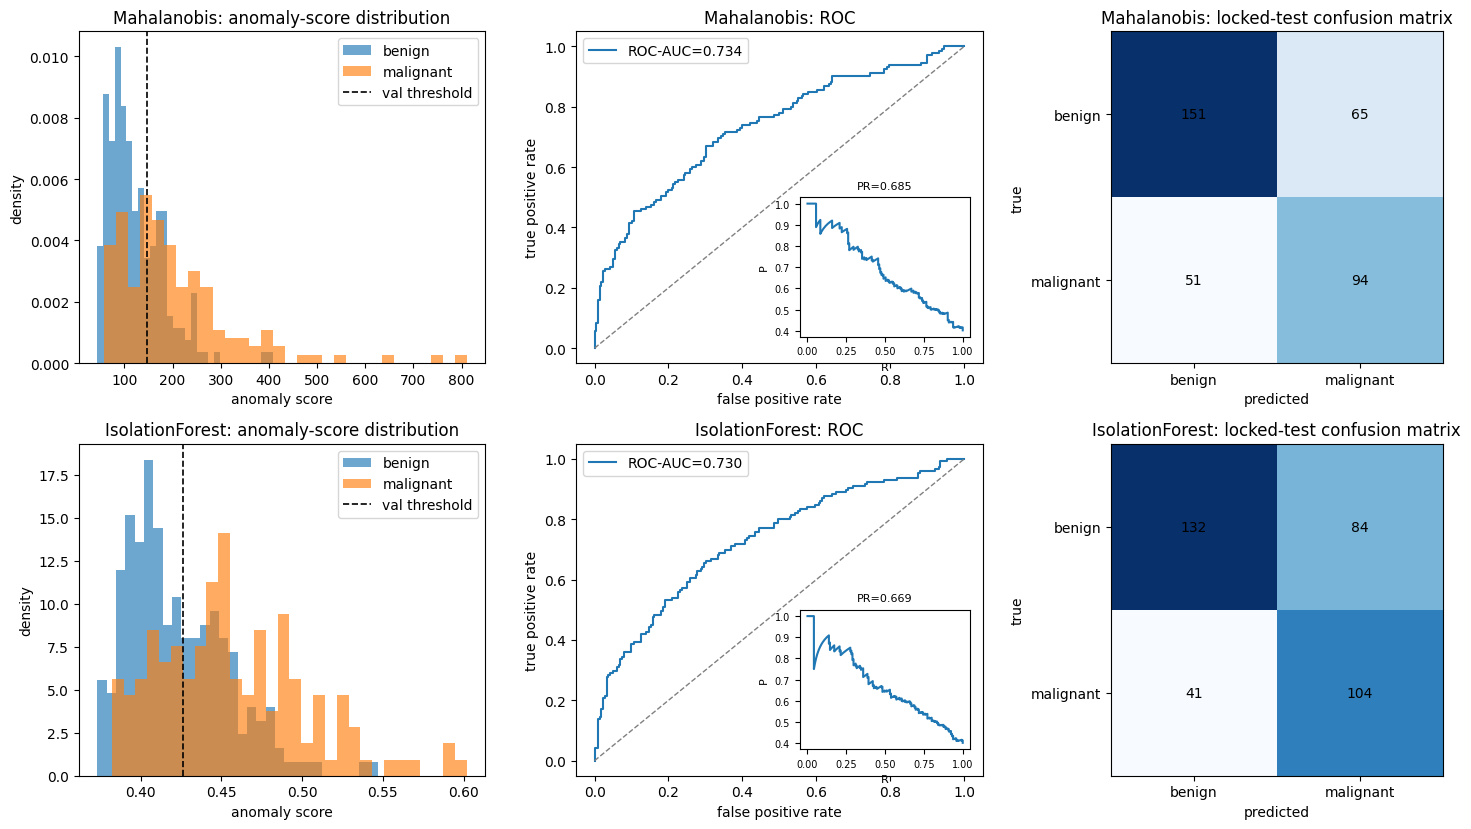

Saved figure: /content/drive/MyDrive/BreastCancer_dissertation/Results/anomaly_detection_oneclass/anomaly_detection_test_figures.png


In [24]:
fig, axes = plt.subplots(len(scores), 3, figsize=(15, 4.2 * len(scores)))
if len(scores) == 1:
    axes = np.array([axes])

for row_idx, method in enumerate(scores.keys()):
    pred = test_pred_df[test_pred_df.method == method].copy()
    th = float(pred.threshold.iloc[0])

    # Score distributions
    ax = axes[row_idx, 0]
    ax.hist(pred.loc[pred.y_true == 0, "anomaly_score"], bins=30, alpha=0.65, label="benign", density=True)
    ax.hist(pred.loc[pred.y_true == 1, "anomaly_score"], bins=30, alpha=0.65, label="malignant", density=True)
    ax.axvline(th, color="black", linestyle="--", linewidth=1.2, label="val threshold")
    ax.set_title(f"{method}: anomaly-score distribution")
    ax.set_xlabel("anomaly score")
    ax.set_ylabel("density")
    ax.legend()

    # ROC and PR curves
    ax = axes[row_idx, 1]
    fpr, tpr, _ = roc_curve(pred.y_true, pred.anomaly_score)
    prec, rec, _ = precision_recall_curve(pred.y_true, pred.anomaly_score)
    ax.plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(pred.y_true, pred.anomaly_score):.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"{method}: ROC")
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.legend()

    ax2 = ax.inset_axes([0.55, 0.08, 0.42, 0.42])
    ax2.plot(rec, prec)
    ax2.set_title(f"PR={average_precision_score(pred.y_true, pred.anomaly_score):.3f}", fontsize=8)
    ax2.set_xlabel("R", fontsize=8)
    ax2.set_ylabel("P", fontsize=8)
    ax2.tick_params(labelsize=7)

    # Confusion matrix
    ax = axes[row_idx, 2]
    cm = confusion_matrix(pred.y_true, pred.y_pred, labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], ["benign", "malignant"])
    ax.set_yticks([0, 1], ["benign", "malignant"])
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{method}: locked-test confusion matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "anomaly_detection_test_figures.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

## 12. Summary and Dissertation Framing

Use this section after running the notebook.

Recommended wording:

> As CBIS-DDSM does not include normal mammograms, anomaly detection was framed as one-class modelling of benign mass cases. A frozen ResNet-50 V2 encoder was used to extract mammogram features, and one-class detectors were fitted using benign training features only. Malignant cases were treated as out-of-distribution relative to the benign feature distribution. Thresholds were selected on the validation set and evaluated once on the locked test set.

Limitations:

- This is not true normal-vs-abnormal screening anomaly detection.
- The feature extractor was supervised during the V2 classification experiment, so the anomaly scorer is one-class but the feature space is not fully unsupervised.
- Cross-dataset external validation was not performed and should be listed as future work.
- A future stricter version could use normal mammograms from VinDr-Mammo or RSNA and compare ImageNet-only, self-supervised, and VAE/autoencoder feature spaces.

In [25]:
config = {
    "created_at": datetime.now().isoformat(),
    "experiment": "benign_oneclass_malignant_detection",
    "dataset": "CBIS-DDSM mass cases",
    "normal_cases_available": False,
    "framing": "one-class modelling of benign mass-case features; malignant cases scored as deviations",
    "encoder": "ResNet-50 V2 breast-crop 512 checkpoint",
    "encoder_checkpoint": V2_MODEL_PATH,
    "image_size": IMG_SIZE,
    "feature_dim": int(train_feat["X"].shape[1]),
    "pca_components": int(n_components),
    "pca_variance_retained": float(pca.explained_variance_ratio_.sum()),
    "methods": list(scores.keys()),
    "threshold_rule": "validation Youden J",
    "bootstrap_n": BOOTSTRAP_N,
    "seed": SEED,
}

with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: /content/drive/MyDrive/BreastCancer_dissertation/Results/anomaly_detection_oneclass
